# Scenario B1 Mixed: Multiple Suppliers — No REC (Mixed Prosumers)

**Description:** Two independent suppliers, no REC, with mixed prosumer profiles.
Prosumers are modelled as **full prosumers** — both local load AND RES generation
are billed, reflecting realistic household-with-PV behaviour.

**Participant–supplier assignment:**
| Supplier / BG | Participants |
|---|---|
| SUP_A / BG_A | prosumer_001 (Fire Station) · consumer_001–004 |
| SUP_B / BG_B | prosumer_002 · prosumer_003 · consumer_005 (Bank) · consumer_006 |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (5 participants), BG_B (4 participants) |
| RECs | None |
| Prosumer type | **Mixed** (RES + local load both billed) |
| Battery | None |

**Research role:** Multi-supplier baseline with realistic prosumer loads.
Compared to A1-mixed, reveals how multi-supplier fragmentation reshapes
each supplier's balancing position and P&L.

**Comparison pairs (mixed-prosumer track):**
- B1-mixed vs A1-mixed → effect of multi-supplier competition (no REC)
- B1-mixed vs B2-mixed → incremental value of adding a cross-supplier REC
- B1-mixed vs B2-forecasts-mixed → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "B1_multiple_supplier_no_rec_mixed.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B1_mixed")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - (Skipped for B1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B1_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B1_mixed
  System  : Multiple Suppliers without REC - Scenario B1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (70272, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B1_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €       48.70
      Balancing Rewards   : €       40.30
      Retail Sales        : €   19,727.93
      ────────────────────────────────────────────
      Total Revenue       : €   19,816.93

    COSTS:
      Market Purchases    : €    3,240.00
      Balancing Penalties  : €       38.32
      Retail Purchases     : €      536.10
      ────────────────────────────────────────────
      Total Costs          : €    3,814.42

    PROFIT/LOSS:
      Annual Total         : €   16,002.51
      Monthly Average      : €    1,333.54

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.02 MWh
      BG Actual Position   :        91.64 MWh
      BG Forecast Position :        91.66 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      290.07
      Balancing Rewards   : €       58.66
      Retail Sales        : €   18,225.46
      ────────

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

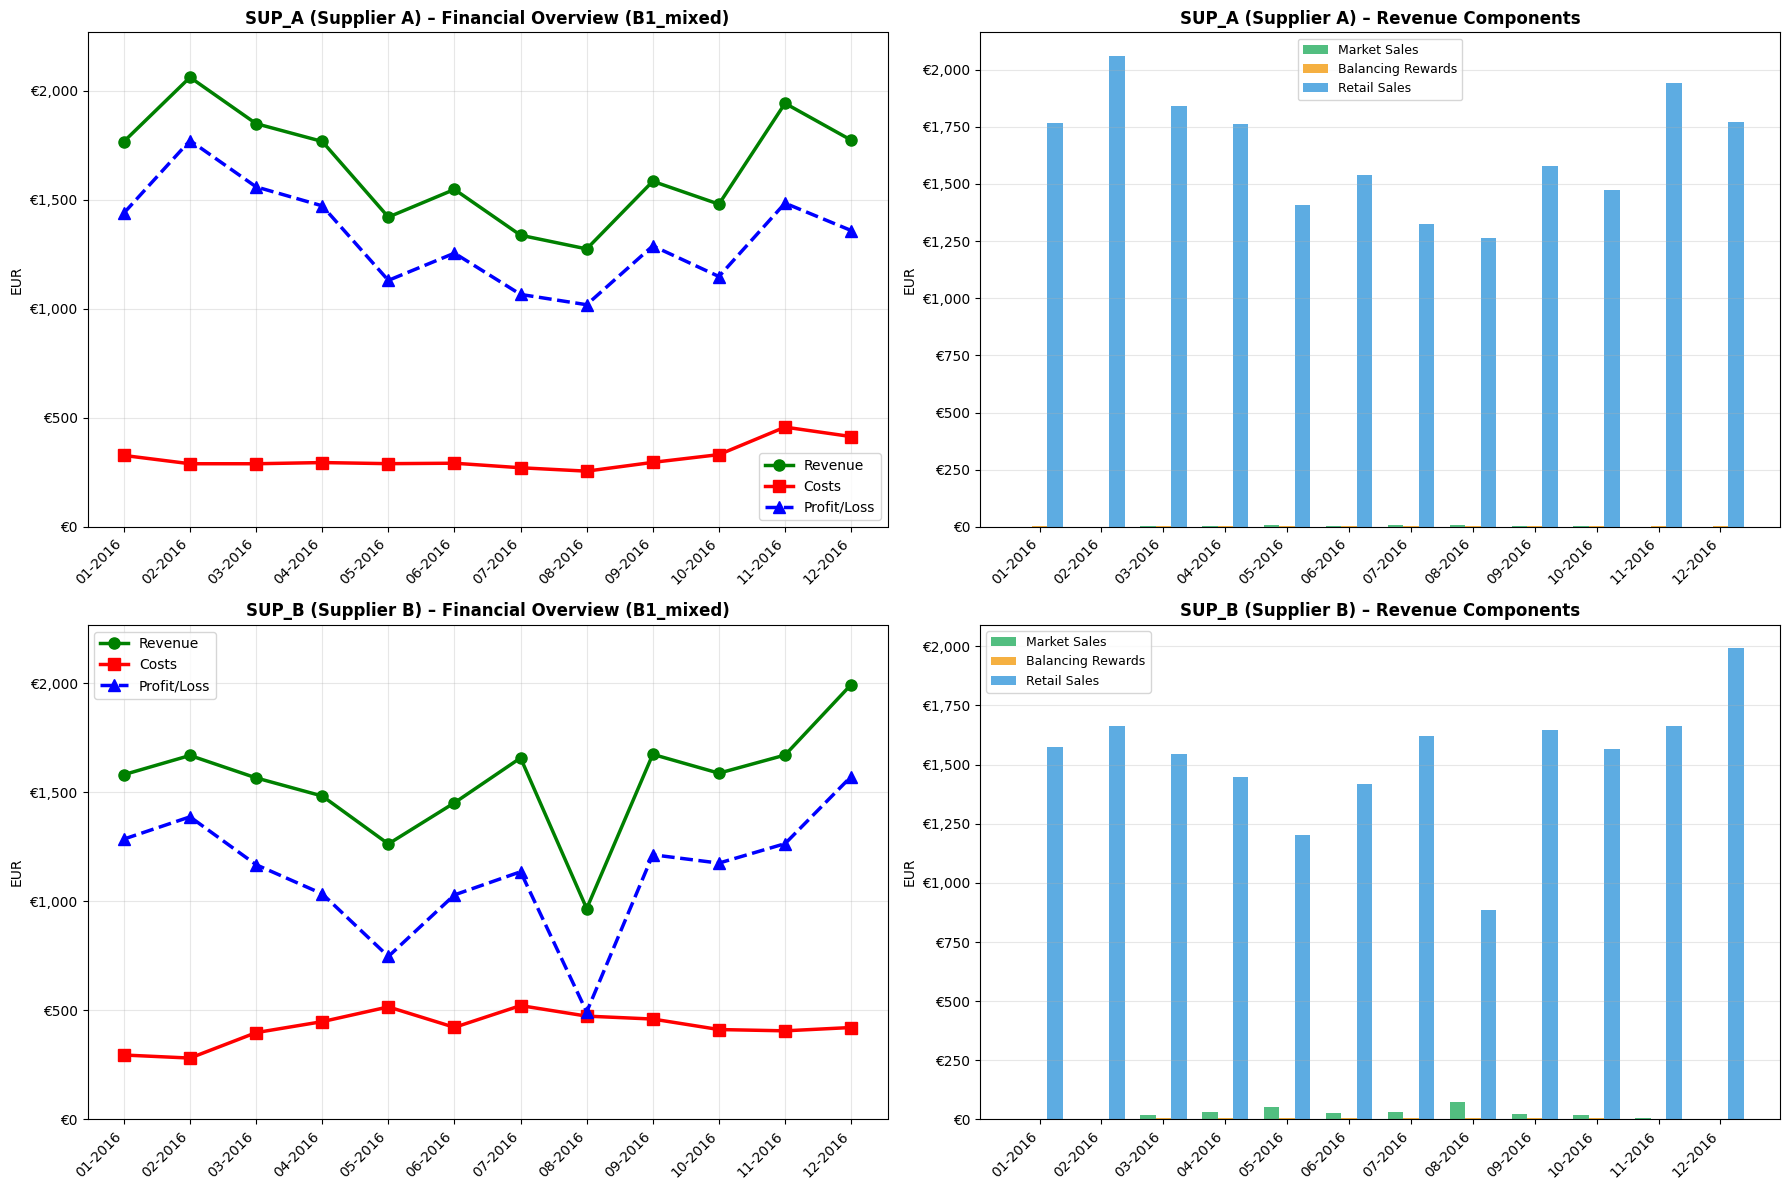

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

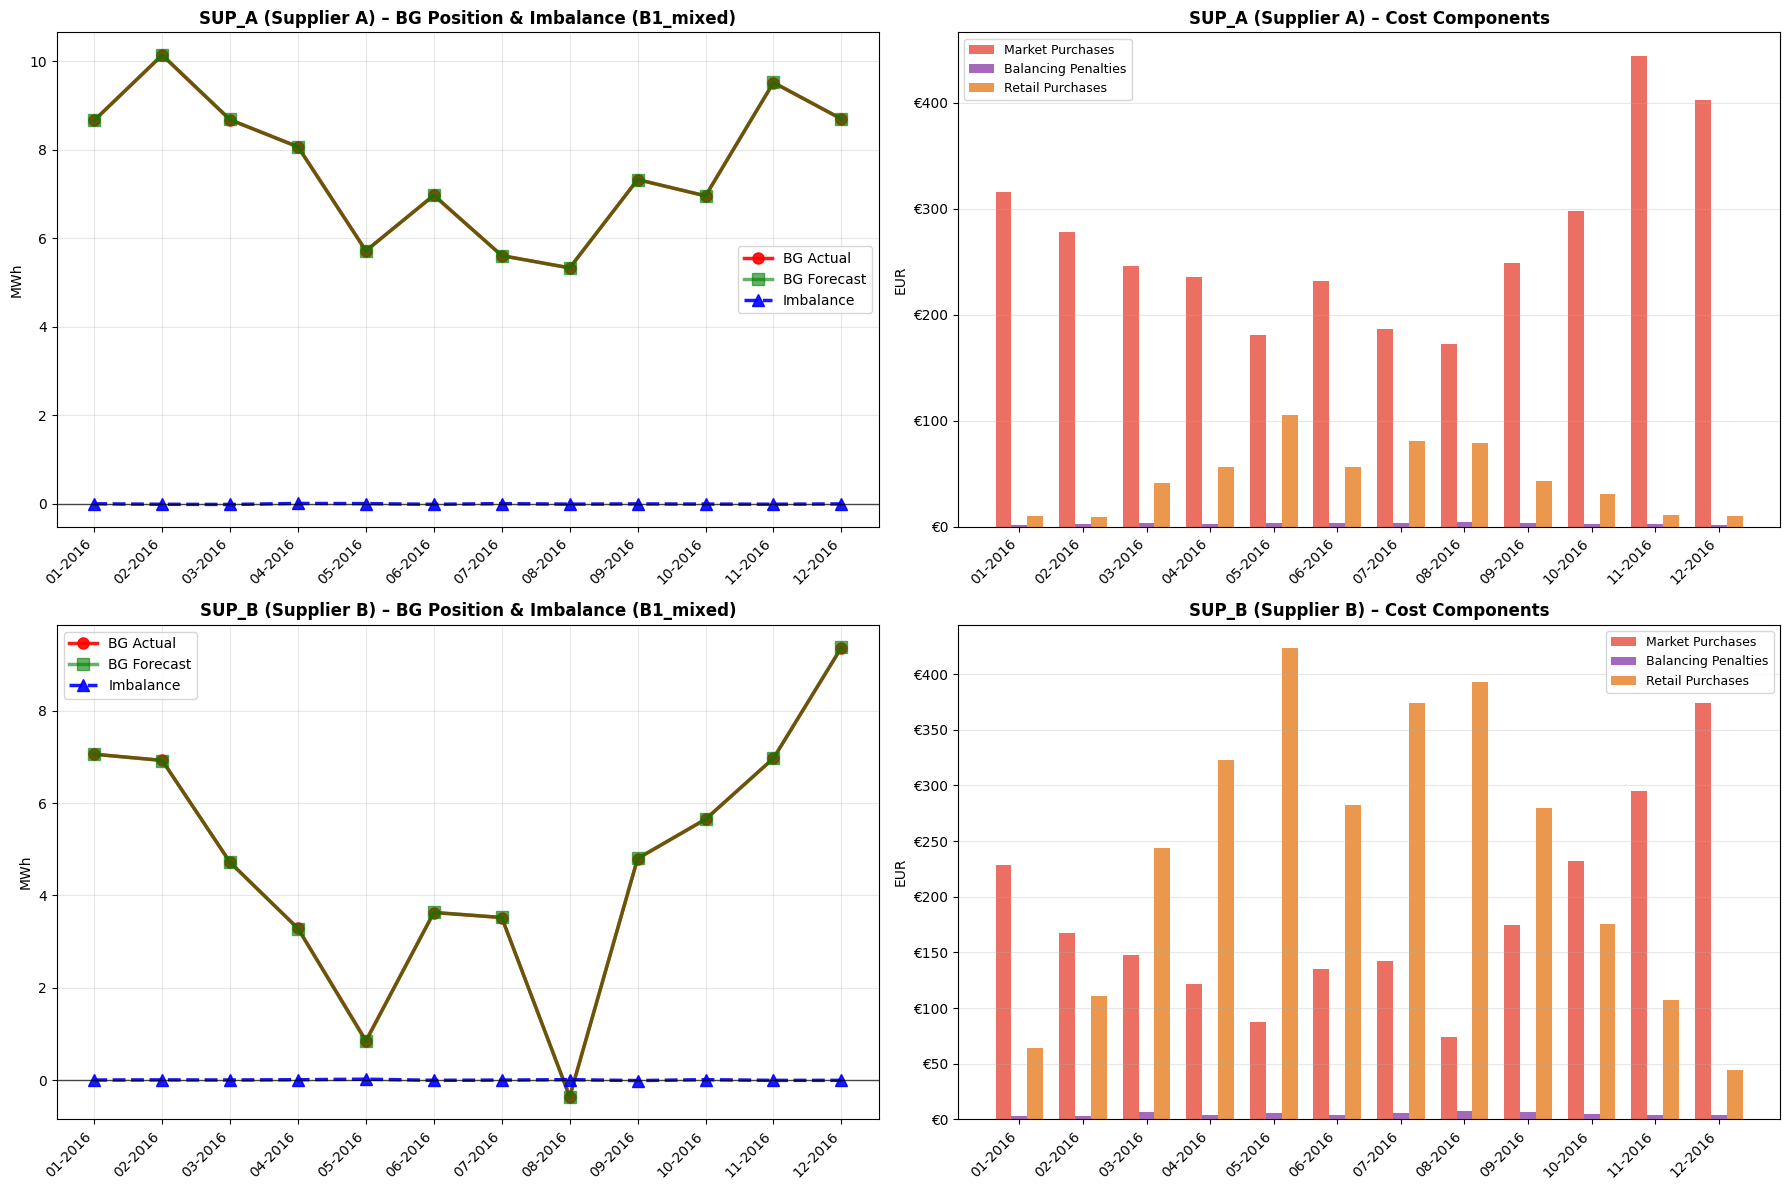

In [6]:
pipe.plot_imbalances()

## 7. Supplier Comparison
Compare financial performance across the two suppliers (SUP_A, SUP_B).

In [7]:
pipe.es_monthly_analysis_df.groupby('supplier_id').agg({
    'profit_loss_eur': 'sum',
    'imbalance_mwh': 'sum'
})

,profit_loss_eur,imbalance_mwh
supplier_id,,
SUP_A,16002.508762,-0.015805
SUP_B,13513.347776,0.015294


In [8]:
from energy_market_operations import EnergyMarketOperations

In [9]:
CONFIG_FILE = "B1_multiple_supplier_no_rec_mixed.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B1_mixed")

In [10]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B1_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B1_mixed
  System  : Multiple Suppliers without REC - Scenario B1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (70272, 8)
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (70272, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (24, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B1_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €       48.70
      Balancing Rewards   : €       40.30
      Retail Sales        : €   19,727.93
      ────────────────────────────────────────────
      Total Revenue       : €   19,816.93

    COSTS:
      Market Purchases    : €    3,240.00
      Balancing Penalties  : €       38.32
      Retail Purchases     : €      536.10
      ────────────────────────────────────────────
      Total Costs          : €    3,814.42

    PROFIT/LOSS:
      Annual Total         : €   16,002.51
      Monthly Average      : €    1,333.54

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.02 MWh
      BG Actual Position   :        91.64 MWh
      BG Forecast Position :        91.66 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      290.07
      Balancing Rewards   : €       58.66
      Retail Sales        : €   18,225.46
      ────────

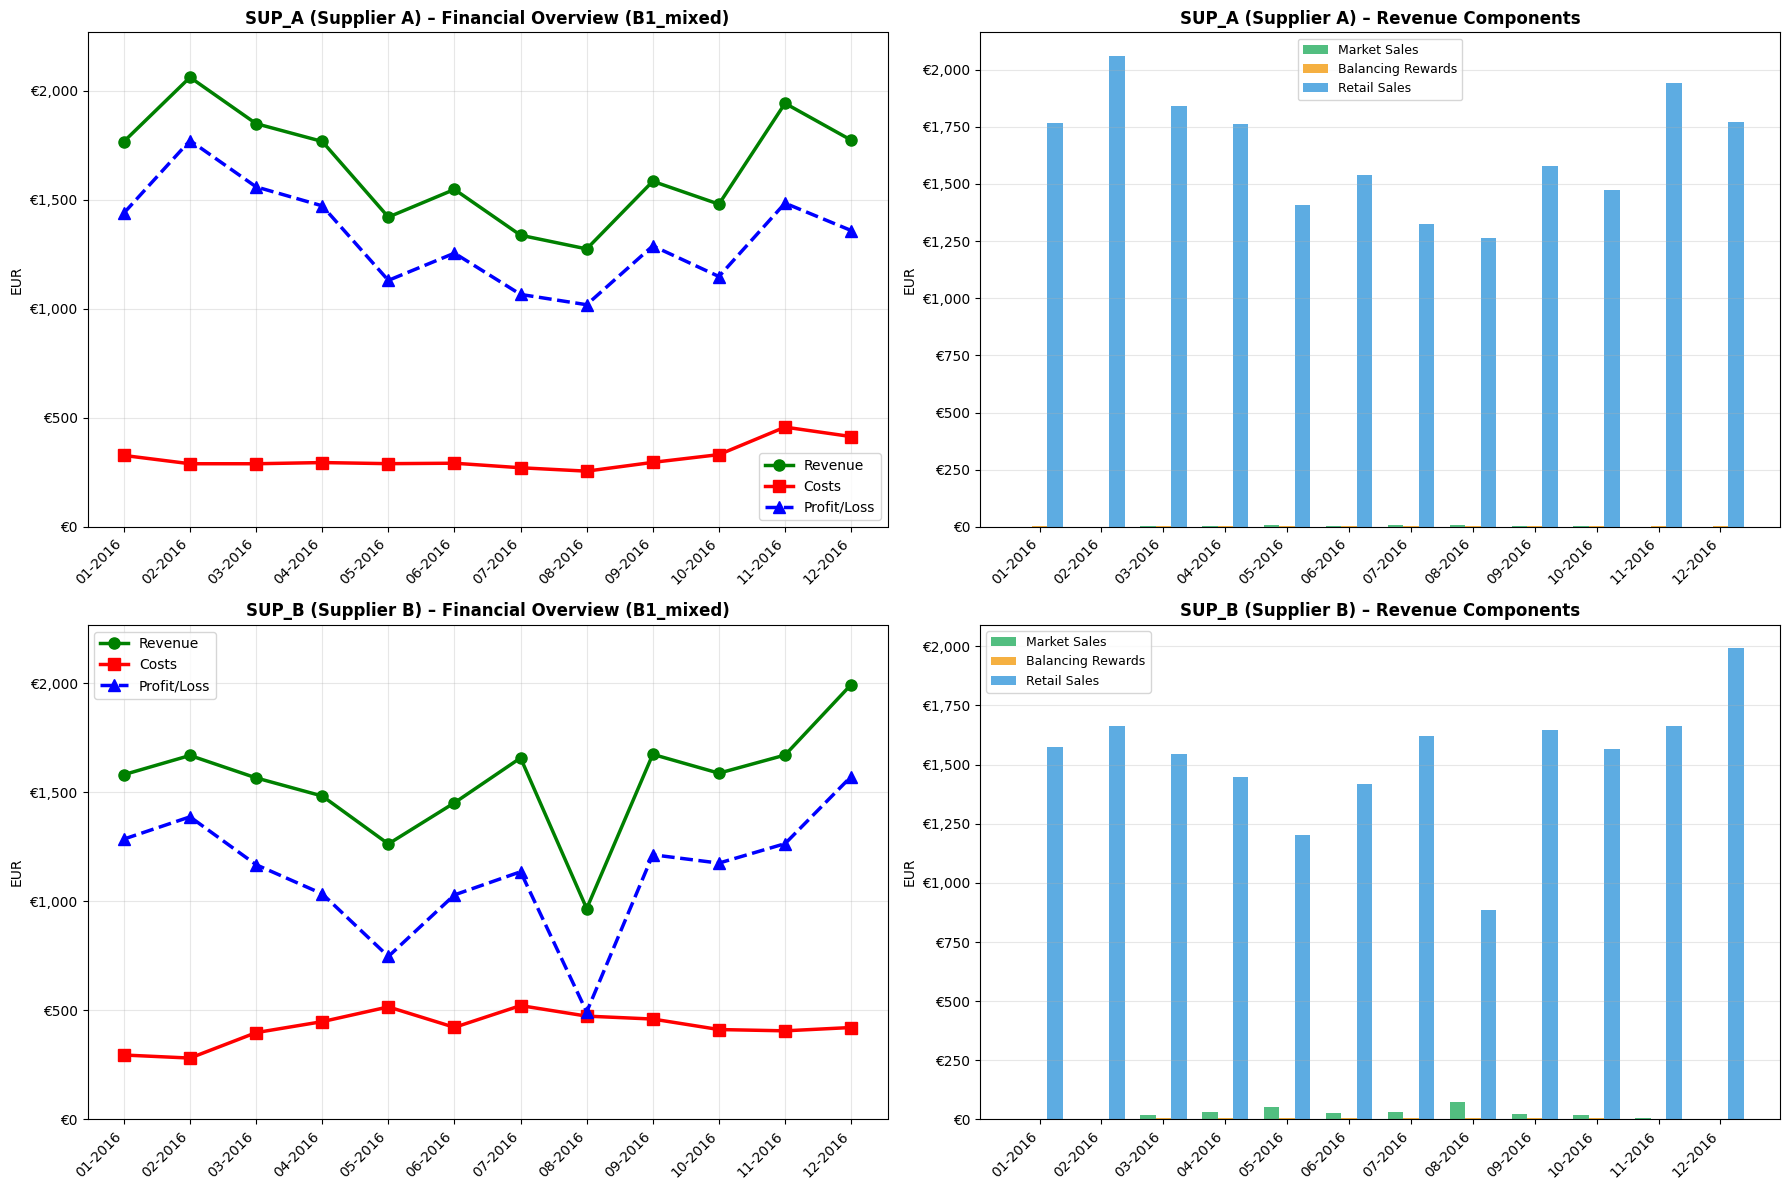

In [12]:
pipe.plot_financials()

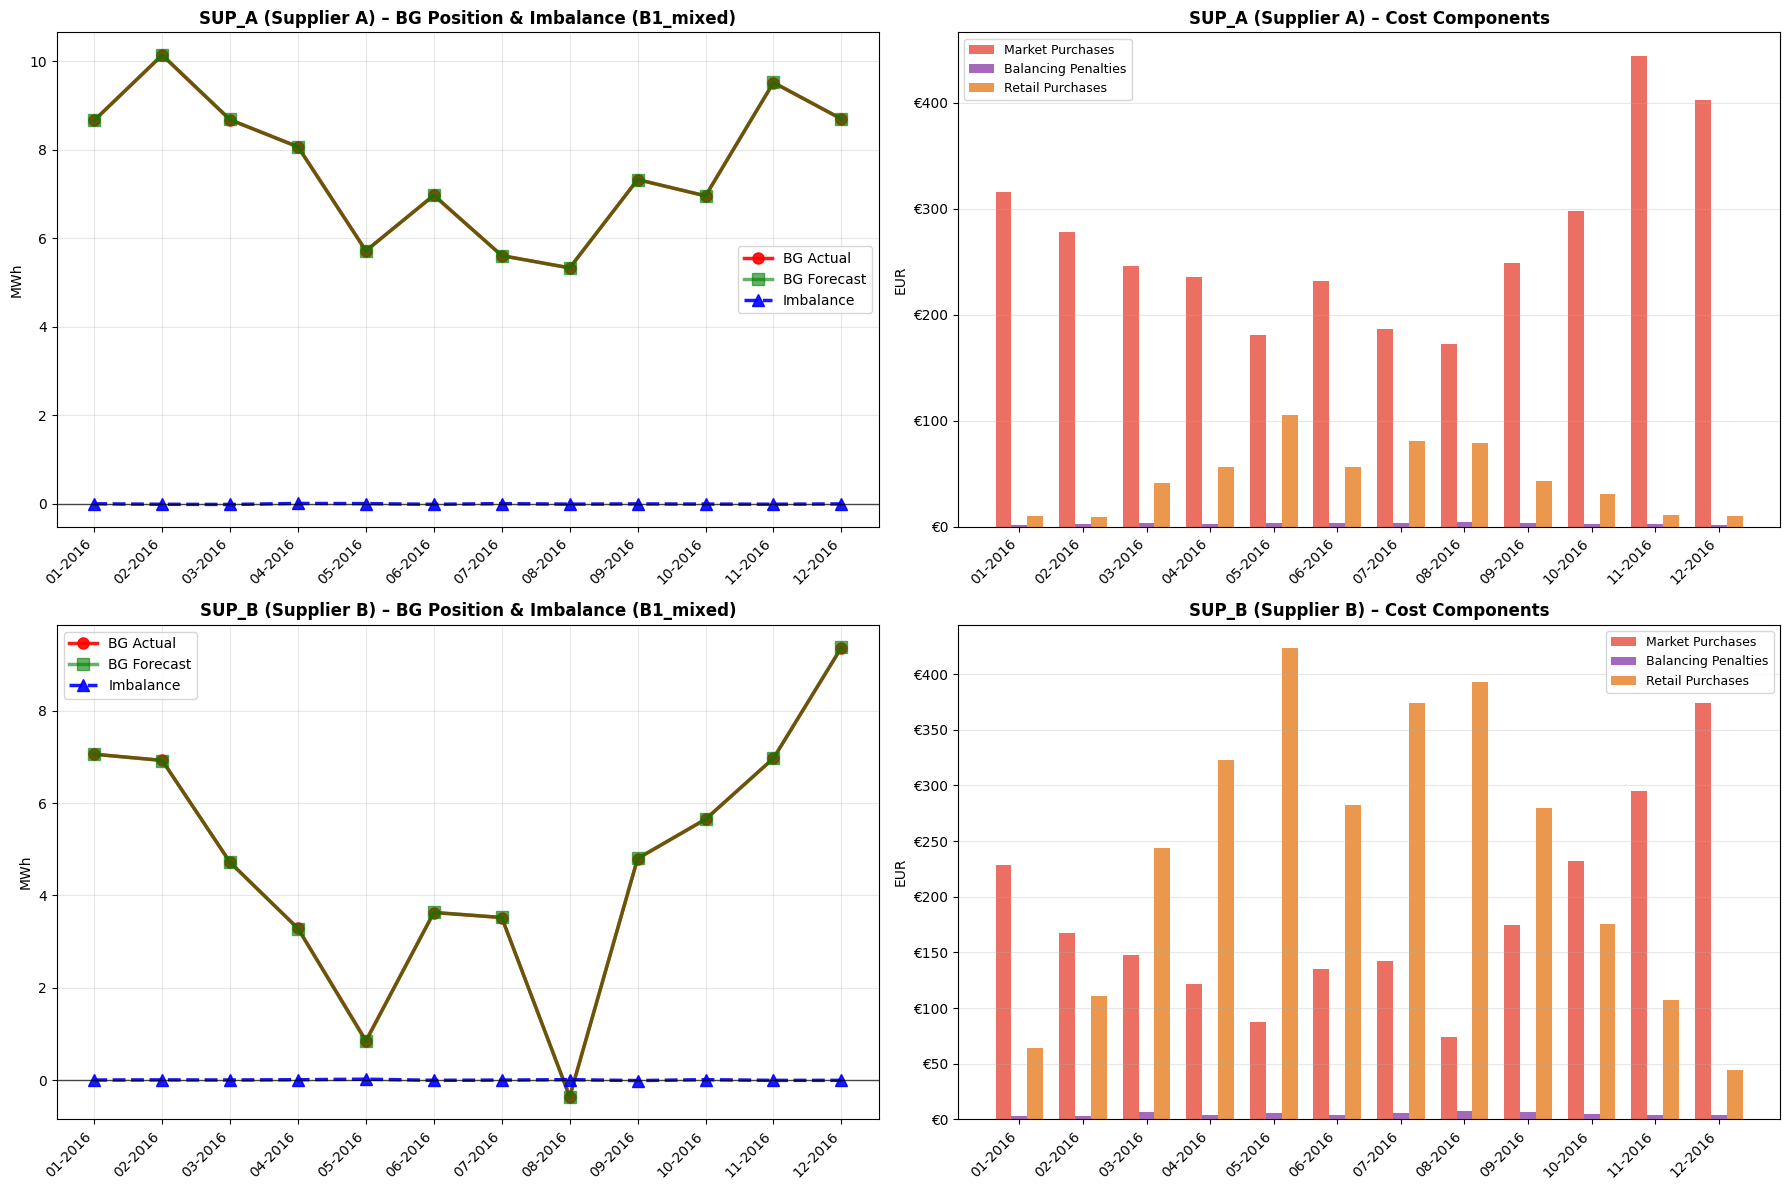

In [13]:
pipe.plot_imbalances()

In [14]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,purchase_costs_eur,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,9.577317,0.015500,348.754292,0.339214,-0.897663,0.005667,29.579375,...,10.015315,0.486466,2.092444,1765.448912,1768.027822,316.103887,1.928345,10.015315,328.047547,1439.980275
1,01-2016,SUP_B,BG_B,7.997181,0.100526,254.835818,2.766790,-0.810626,0.025622,29.579375,...,63.805961,3.477123,3.371682,1574.926368,1581.775174,228.642311,3.163575,63.805961,295.611848,1286.163326
2,02-2016,SUP_A,BG_A,11.240043,0.026621,306.976186,0.398334,-1.066581,0.005263,22.463459,...,9.599306,0.481184,1.971960,2060.258327,2062.711471,277.964371,2.417943,9.599306,289.981621,1772.729850
3,02-2016,SUP_B,BG_B,7.904765,0.075700,188.147221,1.436232,-0.865407,0.039448,22.463459,...,111.126344,2.287565,3.894804,1663.584905,1669.767274,167.103488,3.350235,111.126344,281.580067,1388.187207
4,03-2016,SUP_A,BG_A,9.919988,0.222976,272.846897,3.029804,-0.995564,0.018176,24.094009,...,41.012883,3.361146,3.823642,1842.885476,1850.070264,245.630148,3.298701,41.012883,289.941732,1560.128532
5,03-2016,SUP_B,BG_B,6.442443,0.903479,165.643977,16.623708,-0.694212,0.128343,24.094009,...,243.725995,19.681774,4.443260,1542.743392,1566.868426,147.643038,6.987191,243.725995,398.356223,1168.512203
6,04-2016,SUP_A,BG_A,9.302926,0.233464,263.041821,4.394627,-0.986433,0.026957,25.257687,...,56.921880,4.829420,3.258553,1760.322026,1768.409998,235.409265,3.070641,56.921880,295.401787,1473.008212
7,04-2016,SUP_B,BG_B,5.183689,1.136889,137.026704,25.943463,-0.584233,0.183647,25.257687,...,323.052167,30.532898,4.682844,1448.512002,1483.727745,121.458400,4.163982,323.052167,448.674549,1035.053196
8,05-2016,SUP_A,BG_A,7.103709,0.555605,202.737128,7.746405,-0.772611,0.063829,22.993579,...,105.829288,8.759074,5.140155,1407.546601,1421.445830,180.899842,3.604228,105.829288,290.333357,1131.112473
9,05-2016,SUP_B,BG_B,3.994737,2.493847,99.061593,48.372721,-0.451768,0.213402,22.993579,...,423.050835,53.381897,6.839508,1203.715992,1263.937397,87.544344,5.751784,423.050835,516.346963,747.590434
